# 화재 인명피해 예측 분석 - 그래프 생성

fire.csv를 사용해
1. 타겟(인명피해_발생여부) 분포 막대그래프
2. 혼동행렬 + 특성중요도 그래프

를 생성합니다. fire.csv를 이 노트북과 같은 폴더에 두고 실행하세요.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


### 한글 폰트 설정
윈도우는 보통 '맑은 고딕'이 이미 있어서 아래 그대로 두면 됩니다.
한글이 깨지면 시스템에 있는 한글 폰트 이름/경로로 바꿔주세요.


In [11]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False


### 1. 데이터 불러오기 + 계절 컬럼 추가

In [12]:
df = pd.read_csv('fire.csv', encoding='utf-8-sig')

def month_to_season(m):
    if m in [3, 4, 5]:
        return '봄'
    elif m in [6, 7, 8]:
        return '여름'
    elif m in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['계절'] = df['발생_월'].apply(month_to_season)
df.head()


,시도,화재유형,발화요인대분류,발화요인소분류,장소대분류,인명피해_발생여부,발생_월,발생_시간,발생_요일,계절
0,전북특별자치도,"건축,구조물",부주의,기타(부주의),생활서비스,0,1,0,2,겨울
1,서울특별시,기타(쓰레기 화재등),부주의,담배꽁초,기타,0,1,0,2,겨울
2,경상북도,기타(쓰레기 화재등),부주의,담배꽁초,기타,0,1,0,2,겨울
3,충청북도,"자동차,철도차량",기계적 요인,"과열, 과부하","자동차,철도차량",0,1,0,2,겨울
4,부산광역시,"자동차,철도차량",미상,미상,"자동차,철도차량",0,1,0,2,겨울


### 2. 그래프 1 : 타겟(인명피해_발생여부) 분포 막대그래프

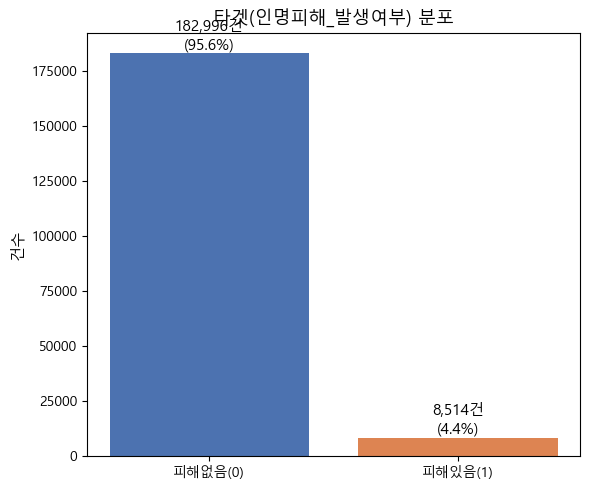

In [13]:
counts = df['인명피해_발생여부'].value_counts().sort_index()
labels = ['피해없음(0)', '피해있음(1)']
values = [counts.get(0, 0), counts.get(1, 0)]
pct = [v / sum(values) * 100 for v in values]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, values, color=['#4C72B0', '#DD8452'])
for b, v, p in zip(bars, values, pct):
    ax.text(b.get_x() + b.get_width() / 2, v + 2000, f'{v:,}건\n({p:.1f}%)',
             ha='center', fontsize=11)
ax.set_title('타겟(인명피해_발생여부) 분포', fontsize=13)
ax.set_ylabel('건수', fontsize=11)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3. 모델 학습
혼동행렬 · 특성중요도 그래프를 그리기 위해 먼저 모델을 학습합니다.


In [14]:
FEATURES = ['발화요인소분류', '장소대분류', '발생_시간', '발생_요일', '계절']
TARGET = '인명피해_발생여부'
NUMERIC = ['발생_시간', '발생_요일']
CATEGORICAL = ['발화요인소분류', '장소대분류', '계절']

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((143632, 5), (47878, 5))

In [15]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
category_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, NUMERIC),
    ('category', category_pipe, CATEGORICAL)
])
model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [16]:
proba = pipeline.predict_proba(X_test)[:, 1]
pred = (proba >= 0.3).astype(int)

report = classification_report(y_test, pred, output_dict=True, zero_division=0)
roc = roc_auc_score(y_test, proba)
cm = confusion_matrix(y_test, pred)

print('ROC-AUC:', round(roc, 4))
print('recall(1):', round(report['1']['recall'], 4))
print('precision(1):', round(report['1']['precision'], 4))


ROC-AUC: 0.7084
recall(1): 0.4908
precision(1): 0.0916


In [17]:
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()

imp_df = pd.DataFrame({'변수': feature_names, '중요도': importances})
imp_df['변수'] = imp_df['변수'].str.replace('numeric__', '', regex=False)\
                                .str.replace('category__', '', regex=False)
imp_df = imp_df.sort_values('중요도', ascending=False)
imp_df.head(15)


,변수,중요도
0,발생_시간,0.340783
1,발생_요일,0.175055
63,장소대분류_주거,0.049607
52,장소대분류_기타,0.039953
2,발화요인소분류_가스누출(폭발),0.023081
21,발화요인소분류_미상,0.021723
24,발화요인소분류_방화,0.021555
19,발화요인소분류_담배꽁초,0.019904
25,발화요인소분류_방화의심,0.018105
68,계절_봄,0.016381


### 4. 그래프 2 : 혼동행렬 + 특성중요도 (한 이미지에 나란히)

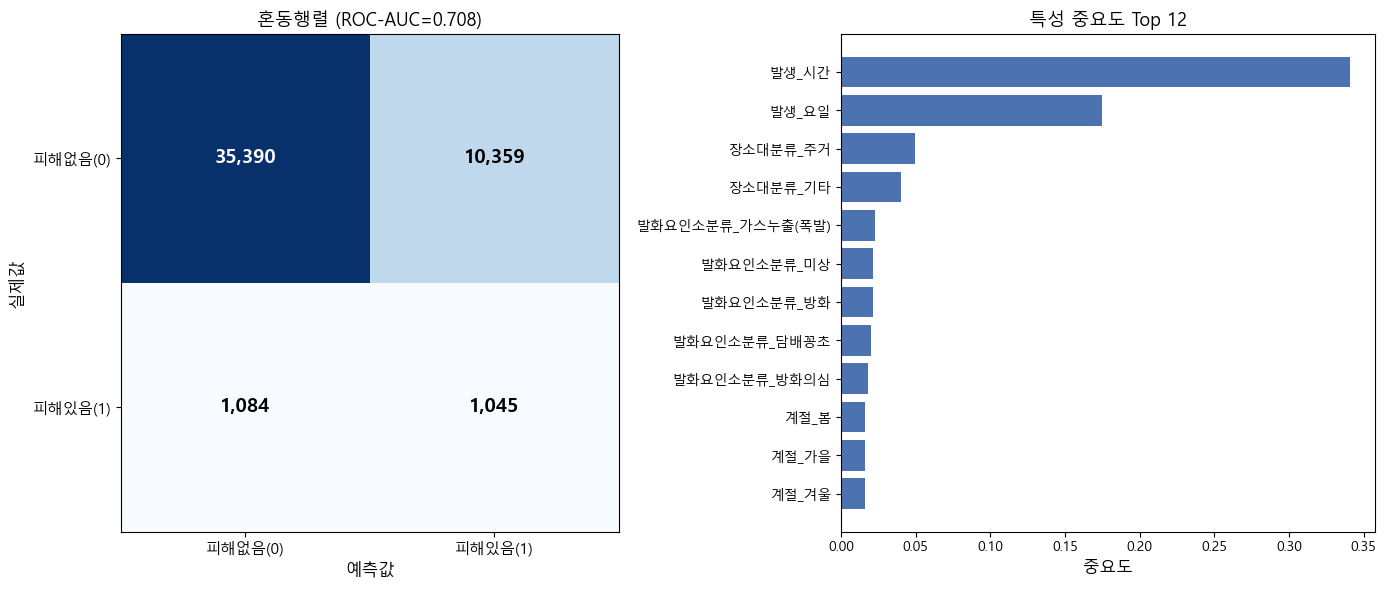

In [18]:
top_n = 12
top = imp_df.head(top_n).sort_values('중요도')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 혼동행렬
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
labels = ['피해없음(0)', '피해있음(1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('예측값', fontsize=12)
ax.set_ylabel('실제값', fontsize=12)
ax.set_title(f'혼동행렬 (ROC-AUC={roc:.3f})', fontsize=13)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black',
                 fontsize=14, fontweight='bold')

# 오른쪽: 특성중요도
ax2 = axes[1]
ax2.barh(top['변수'], top['중요도'], color='#4C72B0')
ax2.set_title(f'특성 중요도 Top {top_n}', fontsize=13)
ax2.set_xlabel('중요도', fontsize=12)

plt.tight_layout()
plt.savefig('fire_classification_result.png', dpi=150, bbox_inches='tight')
plt.show()
